In [1]:
import os 
import sys 
sys.path.append("/home/abharadwaj1/thesis/5_vitrification/utils")
sys.path.append("/home/abharadwaj1/thesis/utils")
from video_utils import get_specific_frame, detect_surface_level, get_line_intensities, detect_time_of_grid_arrival_from_kymograph
from plot_utils import configure_plot_scaling, temporary_rcparams
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from scipy.optimize import curve_fit

# fit a quadratic equation to the x and y values of the edges in the detection range
def quadratic_fn(x, a, b, c):
    """
    Fit a quadratic equation to the given x and y values.
    Returns the coefficients of the quadratic equation.
    """
    return a * x**2 + b * x + c

def inverse_quadratic_fn(y, a, b, c):
    """
    Inverse of the quadratic equation to get x from y.
    Returns the x values corresponding to the given y values.
    """
    determinant = b**2 - 4*a*(c - y)
    root1 = (-b + np.sqrt(b**2 - 4*a*(c - y))) / (2*a)
    root2 = (-b - np.sqrt(b**2 - 4*a*(c - y))) / (2*a)
    # Return the root that is within the detection range
    return (root1, root2)

# Detect edges of the kymograph to measure the air gap thickness 
def detect_edge_from_kymograph(kymograph, kernel_size=6, binarisation_threshold=0.5):
    """
    Detect the edges of the kymograph based on a Canny edge detection algorithm.
    """
    import cv2
    from scipy.ndimage import uniform_filter

    # Convert kymograph to grayscale if it is not already
    if len(kymograph.shape) == 3:
        kymograph_gray = cv2.cvtColor(kymograph, cv2.COLOR_BGR2GRAY)
    else:
        kymograph_gray = kymograph
    
    kymograph_filtered = uniform_filter(kymograph_gray, size=(kernel_size, kernel_size), mode='nearest')
    kymograph_normalised = (kymograph_filtered - kymograph_filtered.min()) / (kymograph_filtered.max() - kymograph_filtered.min())
    kymograph_binarised = (kymograph_normalised < binarisation_threshold).astype(np.uint8)  # Binarise the kymograph
    # Apply Canny edge detection

    edges = cv2.Canny(kymograph_binarised, 0.2, 0.8)
    # return normalised values for edges 
    edges_normalised = edges / edges.max()
    edges_binarised = (edges_normalised > 0.5).astype(int)  # Binarise the edges
    return edges_binarised

def detect_time_of_grid_arrival_from_kymograph(kymograph, reference_pixel_depth=15, threshold=0.99):
    # Using statistical analysis to detect the time of grid arrival
    # kymograph is 2D array with time in x-axis and distance in y-axis
    import numpy as np
    from scipy.ndimage import uniform_filter
    from scipy.stats import norm

    # for each column, calculate the z-score and probabability of grid being present
    # statistical test is to check if the minimum intensity at a column is below the expected minimum value distribution
    
    # first filter the kymograph to remove noise
    kymograph_filtered = uniform_filter(kymograph, size=(6, 6), mode='nearest')
    kymograph_normalised = (kymograph_filtered - kymograph_filtered.min()) / (kymograph_filtered.max() - kymograph_filtered.min())
    kymograph_binarised = (kymograph_normalised < 0.5).astype(int)  # Binarise the kymograph
    
    # find the left most column where the kymograph is not 1 
    projection_y = np.sum(kymograph_binarised, axis=0)
    left_most_column = np.where(projection_y > 0)[0][0]
    

    return left_most_column

def get_yrange_at_each_x(edges_x, edges_y):
    edges_x_unique = np.unique(edges_x)
    thickness_at_ex = {}
    for ex in edges_x_unique:
        indices = np.where(edges_x == ex)[0]
        y_values_at_ex = edges_y[indices]
        max_y_at_ex = np.max(y_values_at_ex)
        min_y_at_ex = np.min(y_values_at_ex)
        thickness_at_ex[ex] = {
            "max_y": max_y_at_ex,
            "min_y": min_y_at_ex,
            "delta": (max_y_at_ex - min_y_at_ex) 
        }
    return thickness_at_ex



In [3]:
data_archive_path = "/home/abharadwaj1/thesis/data_archive"
input_folder = os.path.join(data_archive_path, "inputs", "5_vitrification", "measure_air_gap_for_substrates")
output_folder = os.path.join(data_archive_path, "figures_output", "5_vitrification", "measure_air_gap_for_substrates")
assert os.path.exists(input_folder), f"Input folder {input_folder} does not exist."
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"Created output folder: {output_folder}")

In [4]:
chosen_substrate = "cryosilico" # choose from ["cryochip", "cryosilico", "si_old_chip", "autogrid"]
substrate_folder = os.path.join(input_folder, chosen_substrate)
# get side view video
side_video_path = [os.path.join(substrate_folder, f) for f in os.listdir(substrate_folder) if f.endswith(".mp4") and "side" in f][0]
front_video_path = [os.path.join(substrate_folder, f) for f in os.listdir(substrate_folder) if f.endswith(".mp4") and "front" in f][0]  
print(f"Processing video: {os.path.basename(side_video_path)}")
print(f"Processing video: {os.path.basename(front_video_path)}")

Processing video: newSiChip_side_vid_2025-07-21_19-02-35.mp4
Processing video: newSiChip_front_vid_2025-07-21_19-08-45.mp4


In [7]:
# calibrate using front view 
calibration_frame_number = 1400  # 1400 for cryosilico, xx for cryochip, 1400 for si_old_chip, 1400 for autogrid
calibration_frame = get_specific_frame(front_video_path, calibration_frame_number)
calibration_axis = 565 
y_limit_top = 135
y_limit_bottom = 275 
reference_lengths_dict = {"cryochip": 2e-3, "cryosilico": 3e-3, "si_old_chip": 3.3e-3, "autogrid": 3.5e-3, "autogrid2": 3.5e-3}
reference_length = reference_lengths_dict[chosen_substrate] # in meters, adjust as needed # cryochip = 2e-3, cryosilico = 3e-3, si_old_chip = 3.3e-3, autogrid = 3.5e-3
buffer = 0 
height, width = calibration_frame.shape
intensities = calibration_frame[:, calibration_axis]
apix = reference_length / (y_limit_bottom - y_limit_top)  # pixels per meter
frame_rate = 5406 # fps 
sampling_time = 1 / frame_rate  # seconds per frame
vplunge = 1 # m/s, adjust as needed
print(f"Pixel size: {apix} m/pixel")

Pixel size: 2.1428571428571428e-05 m/pixel


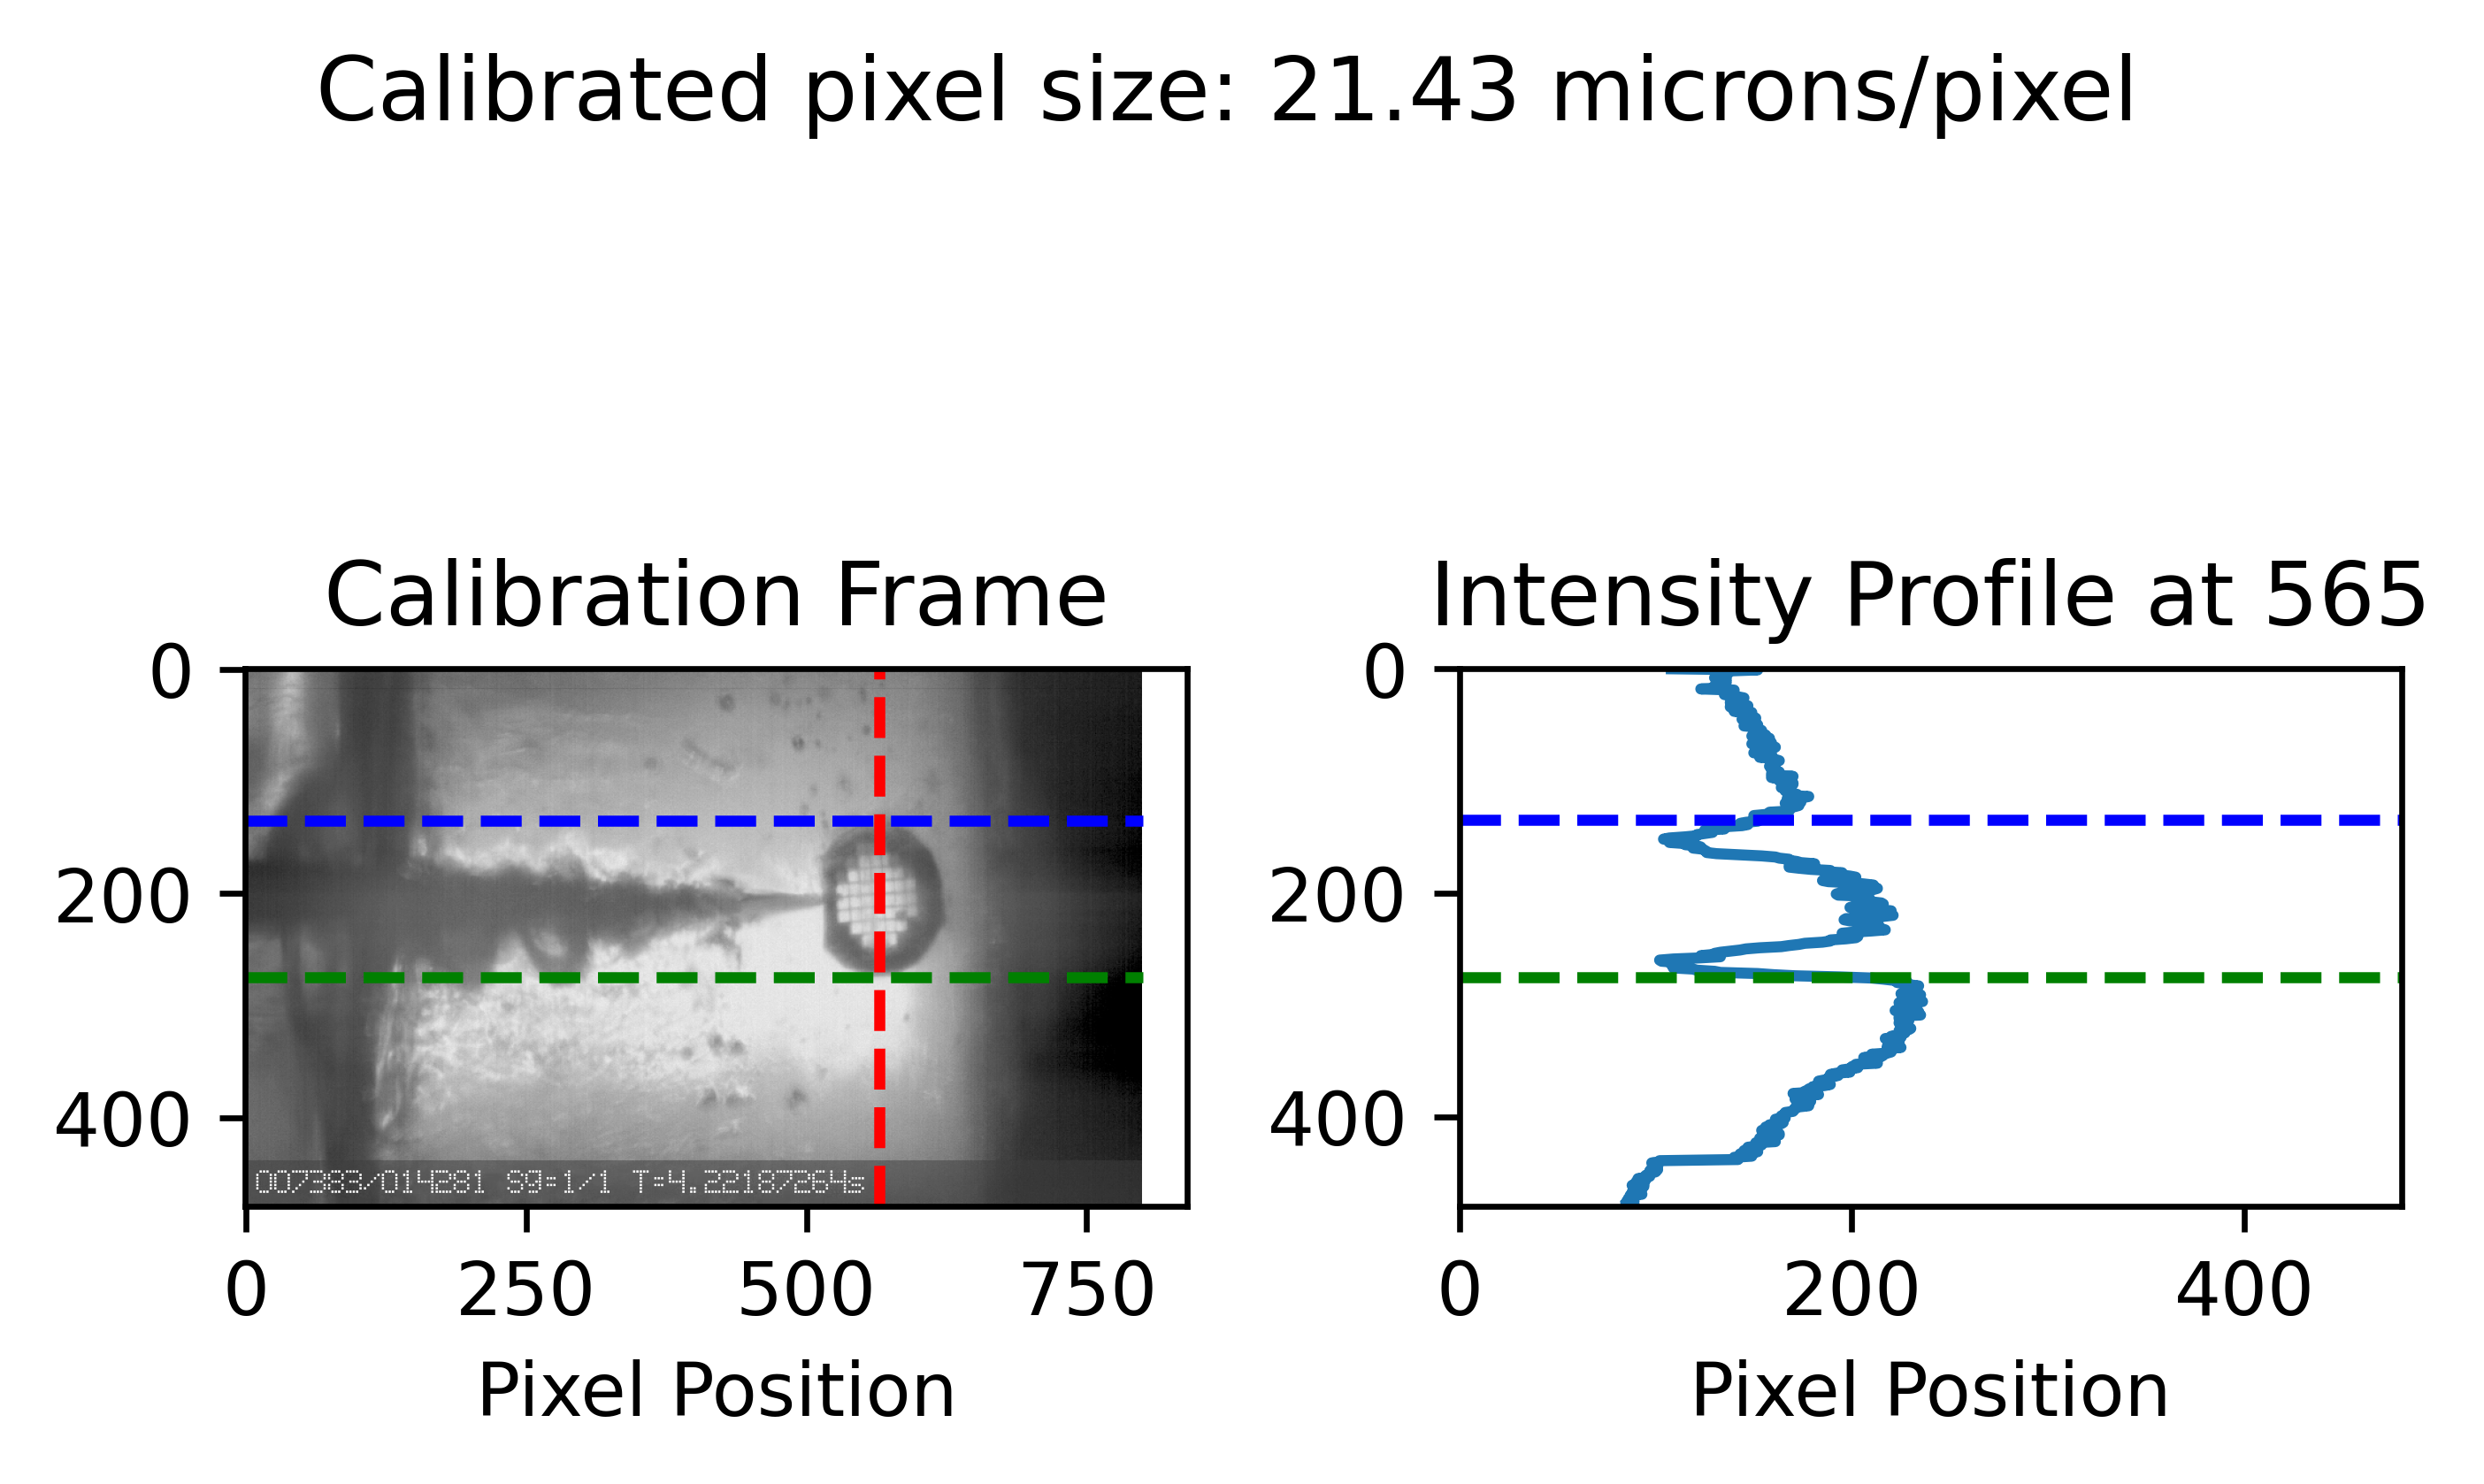

In [8]:
figsize_calibration_mm = (120, 80)
figsize_calibration_in = (figsize_calibration_mm[0] / 25.4, figsize_calibration_mm[1] / 25.4)  # convert mm to inches
fontsize = 8 
# rcParams_calibration = configure_plot_scaling(figsize_calibration_mm)
# rcParams_calibration["font.size"] = fontsize
# with temporary_rcparams(rcParams_calibration):
fig, ax = plt.subplots(1, 2, figsize=figsize_calibration_in, dpi=600)
ax[0].imshow(calibration_frame, cmap='gray')
ax[0].set_title("Calibration Frame")
ax[0].axvline(calibration_axis, color='red', linestyle='--', label='Calibration Axis')
ax[0].plot([0, width], [y_limit_top, y_limit_top], color='blue', linestyle='--', label='Top Limit')
ax[0].plot([0, width], [y_limit_bottom, y_limit_bottom], color='green', linestyle='--', label='Bottom Limit')
ax[0].set_xlabel("Pixel Position")
#ax[0].legend(loc='upper left')
y_points = np.arange(0, height)
ax[1].plot(intensities, y_points)
ax[1].set_title(f"Intensity Profile at {calibration_axis}")
ax[1].set_xlim(buffer, height - buffer)
ax[1].axhline(y_limit_top, color='blue', linestyle='--', label='Top Limit')
ax[1].axhline(y_limit_bottom, color='green', linestyle='--', label='Bottom Limit')
ax[1].set_xlabel("Pixel Position")
#ax[1].legend()
ax[1].invert_yaxis()
ax[1].set_ylim(height - buffer, buffer)
# put both figures have same height
ax[1].set_aspect(ax[0].get_data_ratio())

fig.suptitle(f"Calibrated pixel size: {apix*1e6:.2f} microns/pixel")
fig.tight_layout()
    #fig.savefig(os.path.join(output_folder, f"{chosen_substrate}_calibration.pdf"))


Detected surface level: 102 pixels


/tmp/ipykernel_4200/3815962076.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


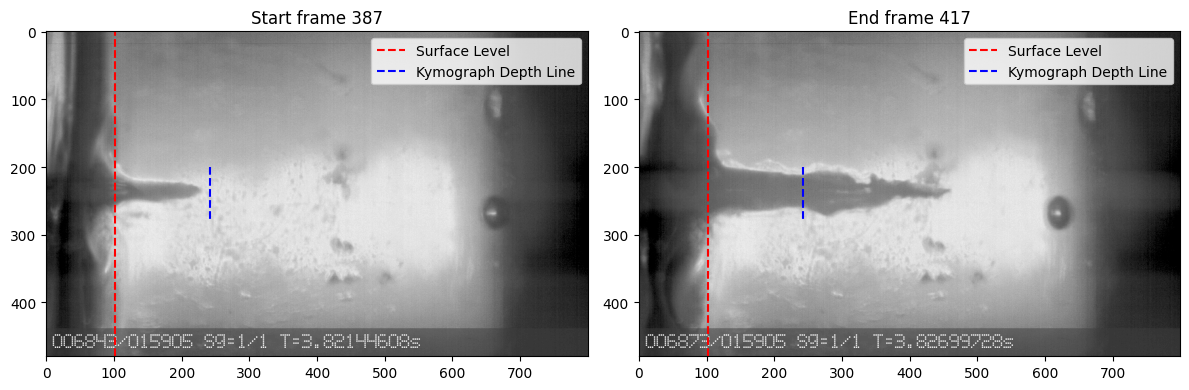

In [12]:
# Analyse side view video for kymograph
kymograph_frame_number_start = 387  # 650 for autogrid, 650 for cryosilico, 800 for si_old_chip, 650 for cryochip
kymograph_frame_number_end = kymograph_frame_number_start + 30
kymograph_frame_number_mean = int((kymograph_frame_number_start + kymograph_frame_number_end) / 2)
kymograph_frame = get_specific_frame(side_video_path, 0)
frame_start = get_specific_frame(side_video_path, kymograph_frame_number_start)
frame_end = get_specific_frame(side_video_path, kymograph_frame_number_end)
surface_level = detect_surface_level(kymograph_frame)[0]
#surface_level = 120 # manually set surface level if detection fails
print(f"Detected surface level: {surface_level} pixels")

kymograph_depth_mm = 3  # depth of the kymograph in mm, adjust as needed
kymograph_depth_m = kymograph_depth_mm * 1e-3  # convert to meters
kymograph_depth_pixels = surface_level + int(kymograph_depth_m / apix)  # convert to pixels
kymograph_y_start = 200
kymograph_y_end = kymograph_y_start + 80
    
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(frame_start, cmap='gray')
ax[0].axvline(surface_level, color='red', linestyle='--', label='Surface Level')
#ax.axvline(kymograph_depth_pixels, color='green', linestyle='--', label='Kymograph Depth')
ax[0].plot([kymograph_depth_pixels, kymograph_depth_pixels], [kymograph_y_start, kymograph_y_end], color='blue', linestyle='--', label='Kymograph Depth Line')
ax[0].set_title(f"Start frame {kymograph_frame_number_start}")
ax[0].legend()
ax[1].imshow(frame_end, cmap='gray')
ax[1].set_title(f"End frame {kymograph_frame_number_end}")
ax[1].axvline(surface_level, color='red', linestyle='--', label='Surface Level')
ax[1].plot([kymograph_depth_pixels, kymograph_depth_pixels], [kymograph_y_start, kymograph_y_end], color='blue', linestyle='--', label='Kymograph Depth Line')
ax[1].legend()
fig.tight_layout()
fig.show()

In [13]:
kymograph = get_line_intensities(side_video_path, \
                                 kymograph_depth_pixels, \
                                kymograph_y_start, kymograph_y_end, \
                                kymograph_frame_number_start, kymograph_frame_number_end
)



Detected time of grid arrival: 71.83 ms


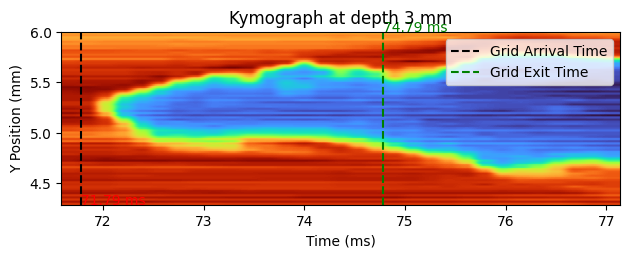

In [14]:
# Plotting the kymograph

time_start_ms = kymograph_frame_number_start * sampling_time * 1000  # convert to milliseconds
time_end_ms = kymograph_frame_number_end * sampling_time * 1000  # convert to milliseconds
y_start = kymograph_y_start * apix * 1e3
y_end = kymograph_y_end * apix * 1e3
detection_result = detect_time_of_grid_arrival_from_kymograph(kymograph, reference_pixel_depth=25, threshold=0.99)

if detection_result is not None:
    grid_arrival_time = time_start_ms + detection_result * sampling_time * 1000 - 0.5 # convert to milliseconds
    print(f"Detected time of grid arrival: {grid_arrival_time:.2f} ms")
else:
    
    print("No grid arrival detected. Enter manually")
    grid_arrival_time = None # manually set if detection fails
grid_arrival_time = time_start_ms+0.2
time_to_cover_substrate = reference_length / vplunge * 1000  # convert to milliseconds
grid_exit_time = grid_arrival_time + time_to_cover_substrate if grid_arrival_time is not None else None

fig, ax = plt.subplots()
ax.imshow(kymograph, aspect='equal', cmap='turbo', extent=[time_start_ms, time_end_ms, y_end, y_start], origin='lower')
ax.set_title(f"Kymograph at depth {kymograph_depth_mm} mm")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Y Position (mm)")
ax.invert_yaxis()
if grid_arrival_time is not None:
    ax.axvline(grid_arrival_time, color='black', linestyle='--', label='Grid Arrival Time')
    ax.text(grid_arrival_time , y_start , f"{grid_arrival_time:.2f} ms", color='red')
if grid_exit_time is not None:
    ax.axvline(grid_exit_time, color='green', linestyle='--', label='Grid Exit Time')
    ax.text(grid_exit_time , y_end , f"{grid_exit_time:.2f} ms", color='green')
ax.legend()
fig.tight_layout()



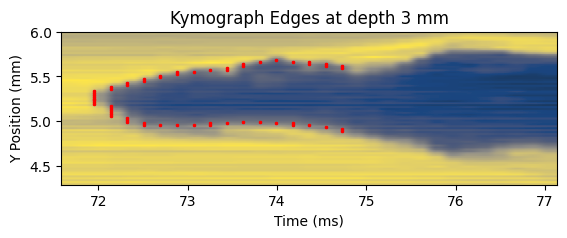

In [15]:
edges = detect_edge_from_kymograph(kymograph, kernel_size=3, binarisation_threshold=0.5)
edges_y, edges_x = np.where(edges > 0)  # Get the coordinates of the edges
edges_x_ms = time_start_ms + edges_x * sampling_time * 1000  # Convert to milliseconds
edges_y_mm =  (y_end - edges_y * apix * 1e3)  # Convert to mm
# Plotting the edges along with the kymograph
fig, ax = plt.subplots()
ax.imshow(kymograph, aspect='equal', cmap='cividis', alpha=0.9, extent=[time_start_ms, time_end_ms, y_end, y_start], origin='lower')
#ax.imshow(edges, aspect='equal', cmap='grey', alpha=0.5, extent=[time_start_ms, time_end_ms, y_end, y_start], origin='lower')
#ax.scatter(edges_x_ms, edges_y_mm, color='black', s=1, label='Kymograph Edges')
edges_x_ms_within_detection_range = edges_x_ms[(edges_x_ms >= grid_arrival_time) & (edges_x_ms <= grid_exit_time)]
edges_y_mm_within_detection_range = edges_y_mm[(edges_x_ms >= grid_arrival_time) & (edges_x_ms <= grid_exit_time)]
# filter edges_y_mm_within_detection_range > 6mm
filter_indices = edges_y_mm_within_detection_range < 6.7
edges_x_ms_within_detection_range = edges_x_ms_within_detection_range[filter_indices]
edges_y_mm_within_detection_range = edges_y_mm_within_detection_range[filter_indices]
ax.scatter(edges_x_ms_within_detection_range, edges_y_mm_within_detection_range, color='red', s=3, label='Kymograph Edges', marker='x')
ax.set_title(f"Kymograph Edges at depth {kymograph_depth_mm} mm")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Y Position (mm)")
ax.invert_yaxis()


In [16]:
thickness_at_ex = get_yrange_at_each_x(edges_x_ms_within_detection_range, edges_y_mm_within_detection_range)
x_fit = np.array(list(thickness_at_ex.keys()))
y_min_values = np.array([thickness_at_ex[ex]["min_y"] for ex in x_fit])
y_max_values = np.array([thickness_at_ex[ex]["max_y"] for ex in x_fit])
thickness_values = np.array([thickness_at_ex[ex]["delta"] for ex in x_fit])
mean_thickness = np.median(thickness_values)
print(f"Mean thickness of air gap: {mean_thickness * 1000:.2f} um at depth {kymograph_depth_mm} mm")


Mean thickness of air gap: 621.43 um at depth 3 mm


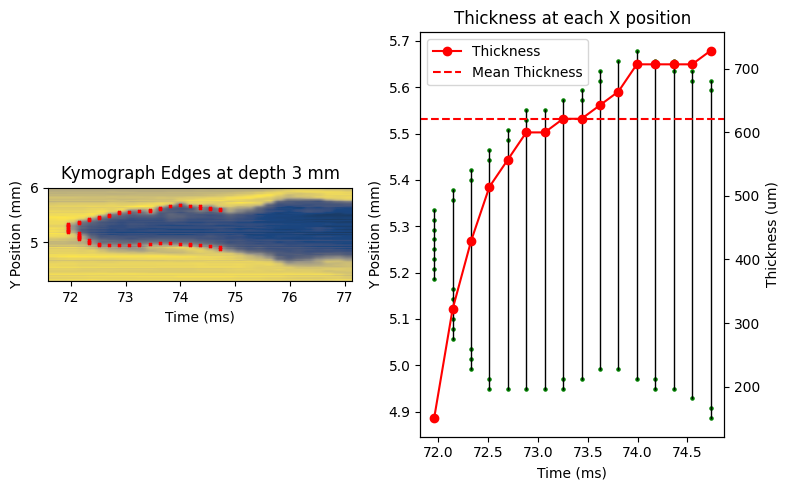

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(8, 5))
ax[0].imshow(kymograph, aspect='equal', cmap='cividis', alpha=0.9, extent=[time_start_ms, time_end_ms, y_end, y_start], origin='lower')
ax[0].scatter(edges_x_ms_within_detection_range, edges_y_mm_within_detection_range, color='red', s=4, label='Kymograph Edges', marker='x')
ax[0].set_title(f"Kymograph Edges at depth {kymograph_depth_mm} mm")
ax[0].set_xlabel("Time (ms)")
ax[0].set_ylabel("Y Position (mm)")
ax[0].invert_yaxis()

ax[1].scatter(edges_x_ms_within_detection_range, edges_y_mm_within_detection_range, color='green', s=5, label='Kymograph Edges')
# plot vertical lines at each x value
for ex in x_fit:
    ax[1].plot([ex, ex], [thickness_at_ex[ex]["min_y"], thickness_at_ex[ex]["max_y"]], color='black', linewidth=1)

# have second y axis for thickness
ax2 = ax[1].twinx()
ax2.plot(x_fit, thickness_values*1000, color='red', marker='o', label='Thickness')
ax2.axhline(mean_thickness * 1000, color='red', linestyle='--', label='Mean Thickness')
ax2.set_ylabel("Thickness (um)")
ax[1].set_title("Thickness at each X position")
ax[1].set_xlabel("Time (ms)")
ax[1].set_ylabel("Y Position (mm)")
# color red ax2
ax2.legend(loc='upper left')
fig.tight_layout()


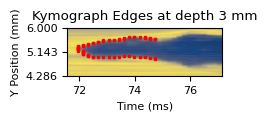

In [18]:
# save figures 
figsize_kymograph_edges = (60, 40)
figsize_kymograph_edges_in = (figsize_kymograph_edges[0] / 25.4, figsize_kymograph_edges[1] / 25.4)  # convert mm to inches
rcParams_kymograph_edges = configure_plot_scaling(figsize_kymograph_edges)
fontsize = 8 

rcParams_kymograph_edges["font.size"] = fontsize
with temporary_rcparams(rcParams_kymograph_edges):
    fig, ax = plt.subplots(figsize=figsize_kymograph_edges_in)  
    ax.imshow(kymograph, aspect='equal', cmap='cividis', alpha=0.9, extent=[time_start_ms, time_end_ms, y_end, y_start], origin='lower')
    ax.scatter(edges_x_ms_within_detection_range, edges_y_mm_within_detection_range, color='red', s=3, label='Kymograph Edges', marker='x')
    ax.set_title(f"Kymograph Edges at depth {kymograph_depth_mm} mm")
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Y Position (mm)")
    yticks_ = np.linspace(y_start, y_end, 3)
    # center to zero 
    ax.set_yticks(yticks_)
    ax.invert_yaxis()
    fig.tight_layout()
    fig.savefig(os.path.join(output_folder, f"{chosen_substrate}_kymograph_edges2.pdf"), dpi=600)

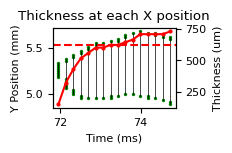

In [19]:
figsize_thickness = (60, 40)
figsize_thickness_in = (figsize_thickness[0] / 25.4, figsize_thickness[1] / 25.4)  # convert mm to inches
rcParams_thickness = configure_plot_scaling(figsize_thickness)
rcParams_thickness["font.size"] = fontsize
with temporary_rcparams(rcParams_thickness):
    fig, ax = plt.subplots(figsize=figsize_thickness_in)  
    ax.scatter(edges_x_ms_within_detection_range, edges_y_mm_within_detection_range, color='green', s=2, label='Kymograph Edges')
    # plot vertical lines at each x value
    for ex in x_fit:
        ax.plot([ex, ex], [thickness_at_ex[ex]["min_y"], thickness_at_ex[ex]["max_y"]], color='black', linewidth=0.5)

    # have second y axis for thickness
    ax2 = ax.twinx()
    ax2.plot(x_fit, thickness_values*1000, color='red', marker='o', label='Thickness', markersize=2)
    ax2.axhline(mean_thickness * 1000, color='red', linestyle='--', label='Mean Thickness')
    ax2.set_ylabel("Thickness (um)")
    ax.set_title("Thickness at each X position")
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Y Position (mm)")
    # color red ax2
    #ax2.legend(loc='upper left')
    fig.tight_layout()
    fig.savefig(os.path.join(output_folder, f"{chosen_substrate}_kymograph_thickness2.pdf"), dpi=600)

In [20]:

calibration_params = {}
calibration_params = {
    "video_file" : front_video_path,
    "calibration_frame_number" : calibration_frame_number,
    "calibration_axis" : calibration_axis,
    "y_limit_top" : y_limit_top,
    "y_limit_bottom" : y_limit_bottom,
    "reference_length_m" : reference_length,
    "apix" : apix,
    "buffer" : buffer,
    "sampling_time_s" : sampling_time,
    "vplunge_m_s" : vplunge,
    "frame_rate_fps" : frame_rate
    
}

# plot parameters
plot_params = {
    "kymograph_frame_number_start" : int(kymograph_frame_number_start),
    "kymograph_frame_number_end" : int(kymograph_frame_number_end),
    "kymograph_depth_mm" : kymograph_depth_mm,
    "kymograph_y_start" : int(kymograph_y_start),
    "kymograph_y_end" : int(kymograph_y_end),
    "surface_level_pixels" : int(surface_level),
    "kymograph_depth_pixels" : int(kymograph_depth_pixels),
    "kymograph_depth_m" : kymograph_depth_m,
    "time_start_ms" : time_start_ms,
    "time_end_ms" : time_end_ms,
    "y_start" : int(y_start),
    "y_end" : int(y_end),
    "grid_arrival_time_ms" : grid_arrival_time,
    "grid_exit_time_ms" : grid_exit_time,
    "edges_x_ms_within_detection_range" : edges_x_ms_within_detection_range.tolist(),
    "edges_y_mm_within_detection_range" : edges_y_mm_within_detection_range.tolist(),
    "thickness_at_ex" : thickness_at_ex,
}

results = {
    "calibration_params": calibration_params,
    "plot_params": plot_params,
    "mean_thickness_um": mean_thickness * 1000,  # convert to microns
}


# dump calibration parameters to a file
import json
calibration_file = os.path.join(input_folder, f"{chosen_substrate}_params.json")
with open(calibration_file, 'w') as f:
    json.dump(results, f, indent=4)
print(f"Calibration parameters saved to {calibration_file}")

Calibration parameters saved to /home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/measure_air_gap_for_substrates/cryosilico_params.json
